# 

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")

print("✅ [INFO] Library berhasil dimuat")

✅ [INFO] Library berhasil dimuat


In [2]:
input_path = '/kaggle/input/datasets/ikhsanfauzan/dataset6/datalogger'

def load_data(path):
    all_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
    temp_list = []
    
    print(f"🔍 [INFO] Jumlah file ditemukan: {len(all_files)}")

    for f in all_files:
        file_name = os.path.basename(f)

        if file_name.startswith('.'):
            continue

        try:
            parts = file_name.replace('.csv', '').split('_')

            # 🔥 FIX ENCODING
            try:
                df_temp = pd.read_csv(f, encoding='utf-16')
                print(f"✅ [UTF-16] {file_name}")
            except:
                df_temp = pd.read_csv(f, encoding='utf-8')
                print(f"✅ [UTF-8] {file_name}")

            df_temp['room'] = parts[3]
            df_temp['time_category'] = parts[4]

            temp_list.append(df_temp)

        except Exception as e:
            print(f"❌ [ERROR] Gagal membaca {file_name}: {e}")

    df = pd.concat(temp_list, ignore_index=True)

    print(f"🔥 [INFO] Total data gabungan: {df.shape[0]} baris")
    return df

df = load_data(input_path)
df.head()

🔍 [INFO] Jumlah file ditemukan: 24
✅ [UTF-16] data_20260309_210624_kamar1_malam.csv
✅ [UTF-8] data_20260317_205301_kamar2_malam.csv
✅ [UTF-8] data_20260317_065105_kamar2_pagi.csv
✅ [UTF-16] data_20260312_061847_hall_pagi.csv
✅ [UTF-16] data_20260312_212452_hall_malam.csv
✅ [UTF-16] data_20260309_140255_kamar1_siang.csv
✅ [UTF-16] data_20260311_120741_kamar3_siang.csv
✅ [UTF-16] data_20260310_201612_kamar2_malam.csv
✅ [UTF-16] data_20260311_093446_kamar3_pagi.csv
✅ [UTF-16] data_20260410_144820_labembedd_siang.csv
✅ [UTF-16] data_20260318_075404_hall_pagi.csv
✅ [UTF-16] data_20260413_095412_kost_pagi.csv
✅ [UTF-8] data_20260316_104917_kamar1_siang.csv
✅ [UTF-8] data_20260316_205002_kamar1_malam.csv
✅ [UTF-16] data_20260410_093822_labembedd_pagi.csv
✅ [UTF-16] data_20260413_092336_kost_pagi.csv
✅ [UTF-16] data_20260316_071731_kamar1_pagi.csv
✅ [UTF-16] data_20260413_103921_kost_siang.csv
✅ [UTF-16] data_20260310_155713_kamar2_siang.csv
✅ [UTF-16] data_20260309_050037_kamar1_pagi.csv
✅ [U

,Timestamp,temperature,humidity,pressure,voc,pir,room,time_category
0,2026-03-09 21:06:46,32.27,83.34,101053,160.54,1,kamar1,malam
1,2026-03-09 21:06:57,31.97,84.17,101054,114.52,1,kamar1,malam
2,2026-03-09 21:07:07,31.74,84.39,101054,91.64,1,kamar1,malam
3,2026-03-09 21:07:17,31.57,84.59,101054,76.77,0,kamar1,malam
4,2026-03-09 21:07:27,31.44,84.72,101055,66.83,0,kamar1,malam


In [3]:
print("🔍 [INFO] Mengecek missing value...")
print(df.isna().sum())

df = df.dropna()

print(f"✅ [INFO] Data setelah cleaning: {df.shape[0]} baris")

🔍 [INFO] Mengecek missing value...
Timestamp        0
temperature      0
humidity         0
pressure         0
voc              0
pir              0
room             0
time_category    0
dtype: int64
✅ [INFO] Data setelah cleaning: 8860 baris


In [4]:
le_room = LabelEncoder()
le_time = LabelEncoder()

df['room_id'] = le_room.fit_transform(df['room'])
df['time_id'] = le_time.fit_transform(df['time_category'])

print("✅ [INFO] Encoding selesai")
print("Mapping Room:", dict(zip(le_room.classes_, le_room.transform(le_room.classes_))))
print("Mapping Time:", dict(zip(le_time.classes_, le_time.transform(le_time.classes_))))

✅ [INFO] Encoding selesai
Mapping Room: {'hall': np.int64(0), 'kamar1': np.int64(1), 'kamar2': np.int64(2), 'kamar3': np.int64(3), 'kost': np.int64(4), 'labembedd': np.int64(5)}
Mapping Time: {'malam': np.int64(0), 'pagi': np.int64(1), 'siang': np.int64(2)}


In [5]:
def define_comfort_label_ashrae(row):
    temp = row['temperature']
    hum = row['humidity']
    voc = row['voc']

    # 🟢 NYAMAN (Standard ASHRAE 55 untuk iklim tropis/Indonesia)
    # Suhu 24-26 (Nyaman Optimal) atau 23-28 (Nyaman Diperbolehkan)
    # Kelembapan ideal 45% - 65%
    if (24 <= temp <= 29.5) and (45 <= hum <= 65) and (voc <= 50):
        return "Nyaman"

    # 🔴 TIDAK NYAMAN (Dibuat hanya untuk kondisi ekstrem)
    # Hanya jika suhu sangat panas atau udara sangat kotor (VOC tinggi)
    if (temp > 32) or (voc > 150) or (temp < 20):
        return "Tidak Nyaman"

    # 🟡 KURANG NYAMAN (Kondisi transisi - Akan menjadi dominan)
    # Contoh: Suhu 28-32 (gerah tapi belum ekstrem) atau kelembapan tinggi (khas Indonesia)
    return "Kurang Nyaman"

df['target'] = df.apply(define_comfort_label_ashrae, axis=1)

print("📊 [INFO] Distribusi Label Baru (ASHRAE Based):")
print(df['target'].value_counts())

📊 [INFO] Distribusi Label Baru (ASHRAE Based):
target
Kurang Nyaman    7839
Nyaman            663
Tidak Nyaman      358
Name: count, dtype: int64


In [6]:
# Mengacak 5-8% label secara random
mask = np.random.rand(len(df)) < 0.08
random_labels = np.random.choice(['Nyaman', 'Kurang Nyaman', 'Tidak Nyaman'], size=mask.sum())
df.loc[mask, 'target'] = random_labels

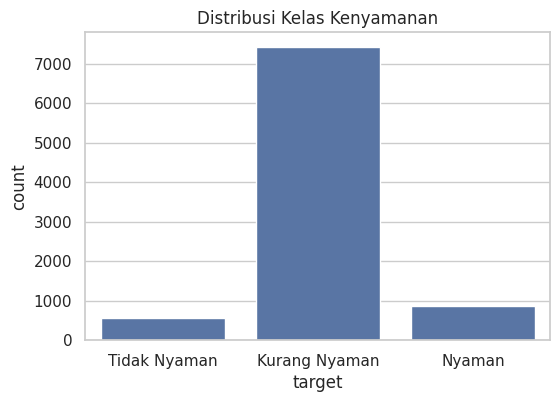

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['target'])
plt.title("Distribusi Kelas Kenyamanan")
plt.show()

In [8]:
features = ['temperature', 'humidity', 'pressure','voc']

X = df[features]
y = df['target']

print("✅ [INFO] Feature & Target siap")
print("Jumlah data:", X.shape)

✅ [INFO] Feature & Target siap
Jumlah data: (8860, 4)


In [9]:
print("🧹 [INFO] Membersihkan format Timestamp...")

# Perbaiki format yang salah
df['Timestamp'] = df['Timestamp'].astype(str)

df['Timestamp'] = df['Timestamp'].str.replace(
    r"(\d{4}-\d{2}):(\d{2})",
    r"\1-\2",
    regex=True
)

# Convert ke datetime (pakai mixed biar aman)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='mixed', errors='coerce')

# Drop data yang gagal convert
before = len(df)
df = df.dropna(subset=['Timestamp'])
after = len(df)

print(f"✅ [INFO] Timestamp fixed. Data tersisa: {after} (drop {before-after})")

🧹 [INFO] Membersihkan format Timestamp...
✅ [INFO] Timestamp fixed. Data tersisa: 8860 (drop 0)


In [10]:
# Menambahkan sedikit noise acak (distribusi normal) ke data sensor
# Agar hubungan antara input dan target tidak 100% kaku
np.random.seed(42)
X_noisy = X.copy()
X_noisy['temperature'] = X_noisy['temperature'] + np.random.normal(0, 0.5, X_noisy.shape[0])
X_noisy['humidity'] = X_noisy['humidity'] + np.random.normal(0, 1.5, X_noisy.shape[0])
X_noisy['voc'] = X_noisy['voc'] + np.random.normal(0, 5, X_noisy.shape[0])

# Gunakan X_noisy ini untuk train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_noisy, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
print("🔄 [INFO] Melakukan Shuffle Split...")

# Menggunakan fitur stratify agar pembagian kelas tetap adil/proporsional
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Ini kunci agar kelas 'Nyaman' yang sedikit tidak hilang
)

print("✅ [INFO] Shuffle split selesai")
print(f"Train: {X_train.shape[0]} baris")
print(f"Test : {X_test.shape[0]} baris")

print("\n📊 Distribusi Train:")
print(y_train.value_counts())

🔄 [INFO] Melakukan Shuffle Split...
✅ [INFO] Shuffle split selesai
Train: 7088 baris
Test : 1772 baris

📊 Distribusi Train:
target
Kurang Nyaman    5938
Nyaman            701
Tidak Nyaman      449
Name: count, dtype: int64


In [12]:
dt_model = DecisionTreeClassifier(
    max_depth=3,            # Kurangi kedalaman dari 6 ke 3 atau 4
    min_samples_leaf=50,    # Paksa setiap daun memiliki minimal 50 sampel
    max_leaf_nodes=10,      # Batasi jumlah total keputusan
    class_weight='balanced', # Tambahkan ini
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("✅ [INFO] Training selesai")

✅ [INFO] Training selesai


In [13]:
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print("\n=== DECISION TREE ===")
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


=== DECISION TREE ===
               precision    recall  f1-score   support

Kurang Nyaman       0.95      1.00      0.97      1484
       Nyaman       0.95      0.77      0.85       175
 Tidak Nyaman       0.92      0.60      0.73       113

     accuracy                           0.95      1772
    macro avg       0.94      0.79      0.85      1772
 weighted avg       0.95      0.95      0.94      1772

Accuracy: 0.9480812641083521

=== RANDOM FOREST ===
               precision    recall  f1-score   support

Kurang Nyaman       0.95      1.00      0.97      1484
       Nyaman       0.96      0.77      0.86       175
 Tidak Nyaman       0.96      0.60      0.74       113

     accuracy                           0.95      1772
    macro avg       0.96      0.79      0.86      1772
 weighted avg       0.95      0.95      0.95      1772

Accuracy: 0.9503386004514672


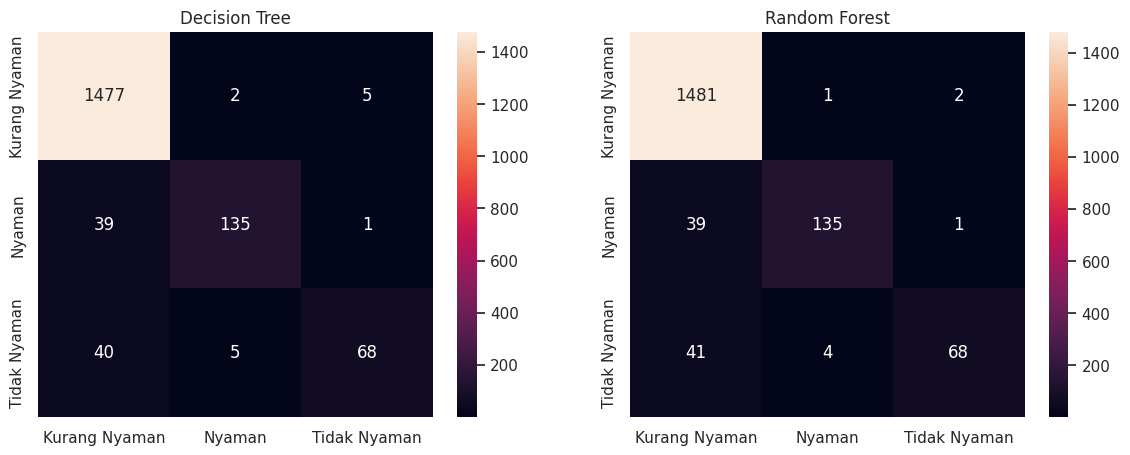

In [14]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True, fmt='d', ax=ax[0],
            xticklabels=dt_model.classes_,
            yticklabels=dt_model.classes_)

ax[0].set_title("Decision Tree")

sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', ax=ax[1],
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)

ax[1].set_title("Random Forest")

plt.show()

In [15]:
print("📌 RULE KONTROL AC:")
rules = export_text(dt_model, feature_names=features)
print(rules)

📌 RULE KONTROL AC:
|--- humidity <= 65.03
|   |--- voc <= 27.99
|   |   |--- humidity <= 61.43
|   |   |   |--- class: Nyaman
|   |   |--- humidity >  61.43
|   |   |   |--- class: Nyaman
|   |--- voc >  27.99
|   |   |--- humidity <= 58.25
|   |   |   |--- class: Nyaman
|   |   |--- humidity >  58.25
|   |   |   |--- class: Nyaman
|--- humidity >  65.03
|   |--- temperature <= 31.99
|   |   |--- pressure <= 101143.50
|   |   |   |--- class: Kurang Nyaman
|   |   |--- pressure >  101143.50
|   |   |   |--- class: Kurang Nyaman
|   |--- temperature >  31.99
|   |   |--- humidity <= 77.92
|   |   |   |--- class: Tidak Nyaman
|   |   |--- humidity >  77.92
|   |   |   |--- class: Tidak Nyaman



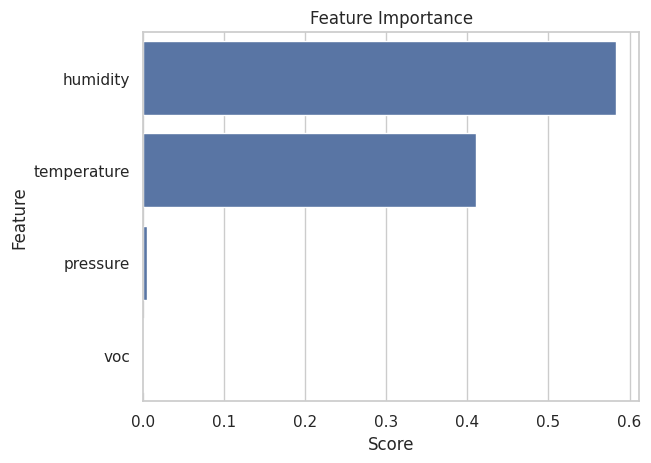

In [16]:
importance = pd.DataFrame({
    'Feature': features,
    'Score': dt_model.feature_importances_
}).sort_values(by='Score', ascending=False)

sns.barplot(x='Score', y='Feature', data=importance)
plt.title("Feature Importance")
plt.show()